# Phân tích tương quan: Sales Count vs các biến khác

Notebook này phục vụ phân tích thống kê (tương quan + kiểm định giả thuyết + hồi quy kiểm chứng) giữa `Sales Count` và các biến còn lại.

## Giả thuyết (cho từng biến X)
- $H_0$: Không có mối liên hệ giữa `Sales Count` và $X$ (hệ số tương quan = 0).
- $H_1$: Có mối liên hệ khác 0.

## Phương pháp
- Pearson: đo quan hệ tuyến tính (nhạy với ngoại lệ).
- Spearman/Kendall: đo quan hệ đơn điệu, bền vững hơn khi phân phối lệch.
- Hiệu chỉnh đa kiểm định: FDR Benjamini–Hochberg (vì kiểm định trên nhiều biến).
- Kiểm chứng bằng mô hình: OLS trên $\log(1+SalesCount)$ (SE robust HC3) và GLM Negative Binomial (phù hợp dữ liệu đếm).

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

# File dữ liệu sau khi join (có Sales Count + Discount Rate)
DEFAULT_PATHS = [
    Path('Data/exports/df_joined.xlsx'),
    Path(r'F:\\project\\NCKH\\Data\\exports\\df_joined.xlsx'),
]
data_path = next((p for p in DEFAULT_PATHS if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Không tìm thấy df_joined.xlsx. Hãy kiểm tra DEFAULT_PATHS.')

df_raw = pd.read_excel(data_path)
print('Loaded:', data_path)
print('Shape:', df_raw.shape)
display(df_raw.head())

Loaded: Data\exports\df_joined.xlsx
Shape: (1435, 29)


,product_id,review_count,avg_rating,content_label_0,content_label_1,content_label_2,content_label_3,physical_label_0,physical_label_1,physical_label_2,...,delivery_label_0,delivery_label_1,delivery_label_2,delivery_label_3,service_label_0,service_label_1,service_label_2,service_label_3,Sales Count,Discount Rate
0,335337,194,4.592784,3,4,82,105,11,2,56,...,5,2,44,143,5,0,10,179,1647,0
1,347334,202,4.673267,1,5,83,113,19,10,70,...,5,3,47,147,1,0,10,191,24533,26
2,356317,8,4.250000,0,0,6,2,0,0,0,...,0,0,0,8,0,0,0,8,415,25
3,377644,181,4.685083,5,12,105,59,4,1,32,...,2,0,34,145,1,0,6,174,38135,30
4,381533,12,4.750000,0,0,8,4,1,0,1,...,0,0,0,12,0,0,0,12,6,0


In [2]:
def clean_column_name(col: str) -> str:
    col = str(col).strip()
    col = re.sub(r',$', '', col)          # bỏ dấu phẩy cuối
    col = re.sub(r'\s+', '_', col)     # space -> underscore
    return col

df = df_raw.copy()
df.columns = [clean_column_name(c) for c in df.columns]

# Xác định cột Sales Count sau khi chuẩn hoá
sales_matches = [c for c in df.columns if ('sales' in c.lower() and 'count' in c.lower())]
if len(sales_matches) != 1:
    raise KeyError(f'Không xác định được cột Sales Count. Matches={sales_matches}')
target_col = sales_matches[0]
print('Target:', target_col)

# Ép kiểu số cho mọi cột trừ khoá
df_num = df.copy()
for c in df_num.columns:
    if c == 'product_id':
        continue
    df_num[c] = pd.to_numeric(df_num[c], errors='coerce')

df_num = df_num.dropna(subset=[target_col])
y = df_num[target_col].astype(float)
display(y.describe())

Target: Sales_Count


count     1435.000000
mean      2333.225087
std       5920.341388
min          1.000000
25%        142.000000
50%        469.000000
75%       1881.500000
max      76652.000000
Name: Sales_Count, dtype: float64

In [3]:
# EDA nhanh: missing rate
missing_rate = df_num.isna().mean().sort_values(ascending=False)
display(missing_rate.head(15))

product_id           0.0
packaging_label_0    0.0
Sales_Count          0.0
service_label_3      0.0
service_label_2      0.0
service_label_1      0.0
service_label_0      0.0
delivery_label_3     0.0
delivery_label_2     0.0
delivery_label_1     0.0
delivery_label_0     0.0
packaging_label_3    0.0
packaging_label_2    0.0
packaging_label_1    0.0
price_label_3        0.0
dtype: float64

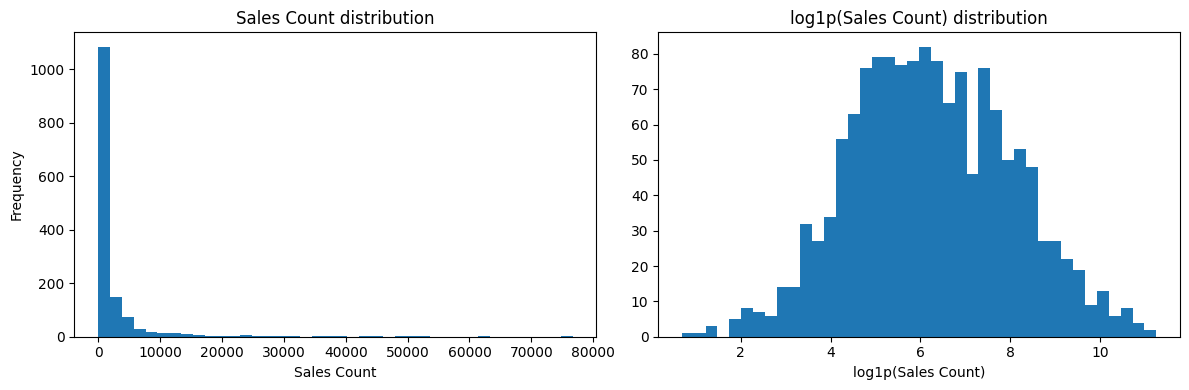

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y.dropna(), bins=40)
ax[0].set_title('Sales Count distribution')
ax[0].set_xlabel('Sales Count')
ax[0].set_ylabel('Frequency')

ax[1].hist(np.log1p(y.dropna()), bins=40)
ax[1].set_title('log1p(Sales Count) distribution')
ax[1].set_xlabel('log1p(Sales Count)')
plt.tight_layout()
plt.show()

In [5]:
from scipy import stats

excluded = {'product_id', target_col}
candidate_features = [c for c in df_num.columns if c not in excluded]

valid_features = []
for c in candidate_features:
    s = df_num[c].dropna()
    if len(s) < 3:
        continue
    if s.nunique() <= 1:
        continue
    valid_features.append(c)

print('Valid features:', len(valid_features))
valid_features[:12]

Valid features: 27


['review_count',
 'avg_rating',
 'content_label_0',
 'content_label_1',
 'content_label_2',
 'content_label_3',
 'physical_label_0',
 'physical_label_1',
 'physical_label_2',
 'physical_label_3',
 'price_label_0',
 'price_label_1']

In [6]:
def compute_correlations(df_numeric: pd.DataFrame, y_col: str, x_cols):
    rows = []
    for x in x_cols:
        tmp = df_numeric[[y_col, x]].dropna()
        if len(tmp) < 3:
            continue
        if tmp[x].nunique() <= 1:
            continue
        pr, pp = stats.pearsonr(tmp[y_col], tmp[x])
        sr, sp = stats.spearmanr(tmp[y_col], tmp[x])
        kt, kp = stats.kendalltau(tmp[y_col], tmp[x])
        rows.append({
            'feature': x,
            'n': len(tmp),
            'pearson_r': pr,
            'pearson_p': pp,
            'spearman_r': sr,
            'spearman_p': sp,
            'kendall_tau': kt,
            'kendall_p': kp,
        })
    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out
    return out.sort_values('spearman_p')

corr_df = compute_correlations(df_num, target_col, valid_features)
display(corr_df.head(20))
print('Tested:', len(corr_df))

,feature,n,pearson_r,pearson_p,spearman_r,spearman_p,kendall_tau,kendall_p
0,review_count,1435,0.699459,2.594765e-211,0.846146,0.000000e+00,0.686482,0.000000e+00
21,delivery_label_3,1435,0.678642,2.701148e-194,0.842760,0.000000e+00,0.682492,0.000000e+00
17,packaging_label_3,1435,0.669973,1.285177e-187,0.844071,0.000000e+00,0.683469,0.000000e+00
25,service_label_3,1435,0.693072,6.166328e-206,0.844248,0.000000e+00,0.683489,0.000000e+00
9,physical_label_3,1435,0.689306,7.850870e-203,0.845892,0.000000e+00,0.687602,0.000000e+00
13,price_label_3,1435,0.693609,2.207988e-206,0.847668,0.000000e+00,0.688730,0.000000e+00
4,content_label_2,1435,0.707494,2.785152e-218,0.813398,0.000000e+00,0.656982,5.251388e-286
5,content_label_3,1435,0.621300,5.567578e-154,0.815978,0.000000e+00,0.643504,1.457862e-280
20,delivery_label_2,1435,0.691358,1.617254e-204,0.795030,1.955351e-313,0.633785,4.993155e-262
8,physical_label_2,1435,0.630002,1.484397e-159,0.781521,6.449879e-296,0.611890,6.241915e-248


Tested: 27


In [7]:
from statsmodels.stats.multitest import multipletests

if len(corr_df) == 0:
    raise ValueError('Không có feature hợp lệ để tính tương quan (quá nhiều NaN/hằng số).')

reject, p_fdr, _, _ = multipletests(corr_df['spearman_p'].values, alpha=0.05, method='fdr_bh')
corr_df = corr_df.assign(spearman_p_fdr=p_fdr, spearman_reject_fdr=reject).sort_values('spearman_p_fdr')
display(corr_df.head(30))
print('Significant after FDR:', int(corr_df['spearman_reject_fdr'].sum()))

,feature,n,pearson_r,pearson_p,spearman_r,spearman_p,kendall_tau,kendall_p,spearman_p_fdr,spearman_reject_fdr
0,review_count,1435,0.699459,2.594765e-211,0.846146,0.000000e+00,0.686482,0.000000e+00,0.000000e+00,True
21,delivery_label_3,1435,0.678642,2.701148e-194,0.842760,0.000000e+00,0.682492,0.000000e+00,0.000000e+00,True
17,packaging_label_3,1435,0.669973,1.285177e-187,0.844071,0.000000e+00,0.683469,0.000000e+00,0.000000e+00,True
25,service_label_3,1435,0.693072,6.166328e-206,0.844248,0.000000e+00,0.683489,0.000000e+00,0.000000e+00,True
9,physical_label_3,1435,0.689306,7.850870e-203,0.845892,0.000000e+00,0.687602,0.000000e+00,0.000000e+00,True
13,price_label_3,1435,0.693609,2.207988e-206,0.847668,0.000000e+00,0.688730,0.000000e+00,0.000000e+00,True
4,content_label_2,1435,0.707494,2.785152e-218,0.813398,0.000000e+00,0.656982,5.251388e-286,0.000000e+00,True
5,content_label_3,1435,0.621300,5.567578e-154,0.815978,0.000000e+00,0.643504,1.457862e-280,0.000000e+00,True
20,delivery_label_2,1435,0.691358,1.617254e-204,0.795030,1.955351e-313,0.633785,4.993155e-262,5.866054e-313,True
8,physical_label_2,1435,0.630002,1.484397e-159,0.781521,6.449879e-296,0.611890,6.241915e-248,1.741467e-295,True


Significant after FDR: 27


In [8]:
# Lưu kết quả tương quan
out_dir = Path('Data/exports')
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'sales_count_correlation_results.csv'
corr_df.to_csv(out_csv, index=False, encoding='utf-8-sig')
print('Saved:', out_csv)

Saved: Data\exports\sales_count_correlation_results.csv


## Kiểm chứng lại giả thuyết bằng hồi quy
- Mô hình 1: OLS với $Y=\log(1+SalesCount)$ và sai số chuẩn robust (HC3). Kiểm định $H_0: \beta_j=0$.
- Mô hình 2: GLM Negative Binomial (dữ liệu đếm, thường phù hợp khi over-dispersion). Kiểm định $H_0: \beta_j=0$.

Thực hành: để tránh mô hình quá nhiều biến, chọn các biến có ý nghĩa theo Spearman+FDR (hoặc top-k theo p-value), rồi chạy hồi quy để kiểm chứng lại.

In [9]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Chọn biến cho hồi quy: ưu tiên biến có ý nghĩa sau FDR; nếu không có thì lấy top 10 theo p-value
sig = corr_df.loc[corr_df['spearman_reject_fdr'], 'feature'].tolist()
if len(sig) == 0:
    sig = corr_df['feature'].head(10).tolist()

# Ưu tiên các biến nền để kiểm soát nhiễu (nếu tồn tại)
for must in ['review_count', 'avg_rating', 'Discount_Rate']:
    if must in df_num.columns and must not in sig:
        sig.append(must)

model_df = df_num[[target_col] + sig].dropna()
y_raw = model_df[target_col].astype(float)
y_log = np.log1p(y_raw)
X = model_df[sig].astype(float)

# Chuẩn hoá (z-score) để so sánh hệ số
X_std = (X - X.mean()) / X.std(ddof=0)
X_std = X_std.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
X_design = sm.add_constant(X_std, has_constant='add')

ols = sm.OLS(y_log, X_design).fit(cov_type='HC3')
print(ols.summary())

bp = het_breuschpagan(ols.resid, ols.model.exog)
bp_labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
print('Breusch–Pagan:', dict(zip(bp_labels, bp)))

                            OLS Regression Results                            
Dep. Variable:            Sales_Count   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                 4.227e+17
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:39:48   Log-Likelihood:                -2206.3
No. Observations:                1435   AIC:                             4457.
Df Residuals:                    1413   BIC:                             4573.
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.2386    6.2e-1

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [10]:
# GLM Negative Binomial (phù hợp dữ liệu đếm)
y_nb = np.round(y_raw).astype(int)
if (y_nb < 0).any():
    raise ValueError('Sales Count có giá trị âm — cần kiểm tra dữ liệu!')

glm_nb = sm.GLM(y_nb, X_design, family=sm.families.NegativeBinomial()).fit()
print(glm_nb.summary())

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            Sales_Count   No. Observations:                 1435
Model:                            GLM   Df Residuals:                     1413
Model Family:        NegativeBinomial   Df Model:                           21
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11114.
Date:                Tue, 07 Apr 2026   Deviance:                       1466.3
Time:                        23:39:49   Pearson chi2:                 1.66e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8674
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.7450      0.02

In [11]:
# Export summary mô hình
summary_path = Path('Data/exports/sales_count_models_summary.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('=== OLS on log1p(Sales Count) with HC3 robust SE ===\n')
    f.write(str(ols.summary()))
    f.write('\n\n=== GLM Negative Binomial on Sales Count ===\n')
    f.write(str(glm_nb.summary()))
print('Saved:', summary_path)

Saved: Data\exports\sales_count_models_summary.txt


## Diễn giải (gợi ý viết báo cáo)
- Ưu tiên kết luận theo Spearman + FDR (bền vững hơn với dữ liệu lệch/ngoại lệ).
- Đối chiếu với hồi quy: biến nào vẫn ý nghĩa trong OLS/GLM thì lập luận mạnh hơn (đã kiểm soát biến khác).
- Nhấn mạnh: dữ liệu quan sát → **không khẳng định nhân quả** nếu không có thiết kế nhân quả/đối chứng.